In [256]:
!pip install phik -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import phik
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

| Название | Описание |
|---|---|
| `AT` | Температура окружающей среды |
| `AP` | Атмосферное давление |
| `AH` | Влажность окружающего воздуха |
| `AFDP` | Перепад давления на воздушном фильтре |
| `GTEP` | Давление выхлопа газовой турбины |
| `TIT` | Температура на входе турбины |
| `TAT` | Температура после турбины |
| `CDP` | Давление на выходе компрессора |
| `TEY` | Выработка энергии турбиной |
| `CO` | Концентрация угарного газа в выбросах |
| `NOx` | Концентрация оксидов азота в выбросах |

## Грузим данные

In [258]:
data_2011 = pd.read_csv('part_2_data/gt_2011.csv')
data_2012 = pd.read_csv('part_2_data/gt_2012.csv')
data_2013 = pd.read_csv('part_2_data/gt_2013.csv')
data_2014 = pd.read_csv('part_2_data/gt_2014.csv')
data_2015 = pd.read_csv('part_2_data/gt_2015.csv')

In [259]:
datasets = [data_2011, data_2012, data_2013, data_2014, data_2015]

In [260]:
data_2011.info()

<class 'pandas.DataFrame'>
RangeIndex: 7411 entries, 0 to 7410
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      7411 non-null   float64
 1   AP      7411 non-null   float64
 2   AH      7411 non-null   float64
 3   AFDP    7411 non-null   float64
 4   GTEP    7411 non-null   float64
 5   TIT     7411 non-null   float64
 6   TAT     7411 non-null   float64
 7   TEY     7411 non-null   float64
 8   CDP     7411 non-null   float64
 9   CO      7411 non-null   float64
 10  NOX     7411 non-null   float64
dtypes: float64(11)
memory usage: 637.0 KB


In [261]:
data_2012.info()

<class 'pandas.DataFrame'>
RangeIndex: 7628 entries, 0 to 7627
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      7628 non-null   float64
 1   AP      7628 non-null   float64
 2   AH      7628 non-null   float64
 3   AFDP    7628 non-null   float64
 4   GTEP    7628 non-null   float64
 5   TIT     7628 non-null   float64
 6   TAT     7628 non-null   float64
 7   TEY     7628 non-null   float64
 8   CDP     7628 non-null   float64
 9   CO      7628 non-null   float64
 10  NOX     7628 non-null   float64
dtypes: float64(11)
memory usage: 655.7 KB


In [262]:
data_2013.info()

<class 'pandas.DataFrame'>
RangeIndex: 7152 entries, 0 to 7151
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      7152 non-null   float64
 1   AP      7152 non-null   float64
 2   AH      7152 non-null   float64
 3   AFDP    7152 non-null   float64
 4   GTEP    7152 non-null   float64
 5   TIT     7152 non-null   float64
 6   TAT     7152 non-null   float64
 7   TEY     7152 non-null   float64
 8   CDP     7152 non-null   float64
 9   CO      7152 non-null   float64
 10  NOX     7152 non-null   float64
dtypes: float64(11)
memory usage: 614.8 KB


In [263]:
data_2014.info()

<class 'pandas.DataFrame'>
RangeIndex: 7158 entries, 0 to 7157
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      7158 non-null   float64
 1   AP      7158 non-null   float64
 2   AH      7158 non-null   float64
 3   AFDP    7158 non-null   float64
 4   GTEP    7158 non-null   float64
 5   TIT     7158 non-null   float64
 6   TAT     7158 non-null   float64
 7   TEY     7158 non-null   float64
 8   CDP     7158 non-null   float64
 9   CO      7158 non-null   float64
 10  NOX     7158 non-null   float64
dtypes: float64(11)
memory usage: 615.3 KB


In [264]:
data_2015.info()

<class 'pandas.DataFrame'>
RangeIndex: 7384 entries, 0 to 7383
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      7384 non-null   float64
 1   AP      7384 non-null   float64
 2   AH      7384 non-null   float64
 3   AFDP    7384 non-null   float64
 4   GTEP    7384 non-null   float64
 5   TIT     7384 non-null   float64
 6   TAT     7384 non-null   float64
 7   TEY     7384 non-null   float64
 8   CDP     7384 non-null   float64
 9   CO      7384 non-null   float64
 10  NOX     7384 non-null   float64
dtypes: float64(11)
memory usage: 634.7 KB


In [265]:
new_datasets = []

In [266]:
# Соединим датасеты
for year, dataset in zip(range(2011, 2016), datasets):
    dataset['year'] = year
    new_datasets.append(dataset)

data = pd.concat(new_datasets, ignore_index=True)
data.info()
    

<class 'pandas.DataFrame'>
RangeIndex: 36733 entries, 0 to 36732
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      36733 non-null  float64
 1   AP      36733 non-null  float64
 2   AH      36733 non-null  float64
 3   AFDP    36733 non-null  float64
 4   GTEP    36733 non-null  float64
 5   TIT     36733 non-null  float64
 6   TAT     36733 non-null  float64
 7   TEY     36733 non-null  float64
 8   CDP     36733 non-null  float64
 9   CO      36733 non-null  float64
 10  NOX     36733 non-null  float64
 11  year    36733 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 3.4 MB


In [267]:
data.to_csv('combined_data.csv', index=False)

## EDA

| Название | Описание |
|---|---|
| `AT` | Температура окружающей среды |
| `AP` | Атмосферное давление |
| `AH` | Влажность окружающего воздуха |
| `AFDP` | Перепад давления на воздушном фильтре |
| `GTEP` | Давление выхлопа газовой турбины |
| `TIT` | Температура на входе турбины |
| `TAT` | Температура после турбины |
| `CDP` | Давление на выходе компрессора |
| `TEY` | Выработка энергии турбиной |
| `CO` | Концентрация угарного газа в выбросах |
| `NOx` | Концентрация оксидов азота в выбросах |

***Данные представляют собой почасовые агрегированные измерения газовой турбины и отсортированы в хронологическом порядке***

In [268]:
data = pd.read_csv('combined_data.csv')
data.head()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX,year
0,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,0.32663,81.952,2011
1,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,0.44784,82.377,2011
2,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,0.45144,83.776,2011
3,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,0.23107,82.505,2011
4,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,0.26747,82.028,2011


In [269]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 36733 entries, 0 to 36732
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      36733 non-null  float64
 1   AP      36733 non-null  float64
 2   AH      36733 non-null  float64
 3   AFDP    36733 non-null  float64
 4   GTEP    36733 non-null  float64
 5   TIT     36733 non-null  float64
 6   TAT     36733 non-null  float64
 7   TEY     36733 non-null  float64
 8   CDP     36733 non-null  float64
 9   CO      36733 non-null  float64
 10  NOX     36733 non-null  float64
 11  year    36733 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 3.4 MB


In [270]:
data.isna().sum()

AT      0
AP      0
AH      0
AFDP    0
GTEP    0
TIT     0
TAT     0
TEY     0
CDP     0
CO      0
NOX     0
year    0
dtype: int64

In [271]:
data.duplicated().sum()

np.int64(7)

Посмотрим на дубликаты

In [272]:
data[data.duplicated(keep=False)]

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX,year
26398,23.156,1004.2,95.938,4.0547,24.672,1076.6,549.87,127.01,11.835,1.7056,47.352,2014
26399,23.156,1004.2,95.938,4.0547,24.672,1076.6,549.87,127.01,11.835,1.7056,47.352,2014
26400,23.156,1004.2,95.938,4.0547,24.672,1076.6,549.87,127.01,11.835,1.7056,47.352,2014
26401,23.156,1004.2,95.938,4.0547,24.672,1076.6,549.87,127.01,11.835,1.7056,47.352,2014
26402,23.156,1004.2,95.938,4.0547,24.672,1076.6,549.87,127.01,11.835,1.7056,47.352,2014
27388,26.067,1008.3,87.328,5.0703,29.984,1099.1,546.78,146.14,13.038,1.3163,52.564,2014
27389,26.067,1008.3,87.328,5.0703,29.984,1099.1,546.78,146.14,13.038,1.3163,52.564,2014
27390,26.067,1008.3,87.328,5.0703,29.984,1099.1,546.78,146.14,13.038,1.3163,52.564,2014
27391,26.067,1008.3,87.328,5.0703,29.984,1099.1,546.78,146.14,13.038,1.3163,52.564,2014


Заметим, что полные дубликаты у нас есть только в 2014 году

Также видно, что записи о наблюдениях идут друг за другом по индексам, а значит скорее всего это ошибка - поэтому удалим дубликаты

In [273]:
data.drop_duplicates(inplace=True)

In [274]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
AT,36726.0,17.711451,7.447561,-6.234800,11.779250,17.79800,23.66400,37.1030
AP,36726.0,1013.071521,6.463155,985.850000,1008.800000,1012.60000,1017.00000,1036.6000
AH,36726.0,77.864274,14.461250,24.085000,68.182500,80.46550,89.37375,100.2000
AFDP,36726.0,3.925410,0.773939,2.087400,3.355525,3.93745,4.37680,7.6106
GTEP,36726.0,25.563537,4.196157,17.698000,23.127250,25.10450,29.05900,40.7160
TIT,36726.0,1081.427166,17.537244,1000.800000,1071.800000,1085.90000,1097.00000,1100.9000
TAT,36726.0,546.158062,6.842901,511.040000,544.720000,549.88000,550.04000,550.6100
TEY,36726.0,133.506079,15.619558,100.020000,124.450000,133.73000,144.08000,179.5000
CDP,36726.0,12.060470,1.088861,9.851800,11.434000,11.96500,12.85375,15.1590
CO,36726.0,2.372627,2.262856,0.000388,1.182325,1.71370,2.84335,44.1030


Тут сложно что то сказать - видно только что данные имеют разный масштаб

In [275]:
data.shape

(36726, 12)

In [276]:
cols = data.drop(columns=['year']).columns.tolist()
print(cols)

['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP', 'CO', 'NOX']


### Смотрим распредеения

------------ Описание AT ---------------


count    36726.000000
mean        17.711451
std          7.447561
min         -6.234800
25%         11.779250
50%         17.798000
75%         23.664000
max         37.103000
Name: AT, dtype: float64

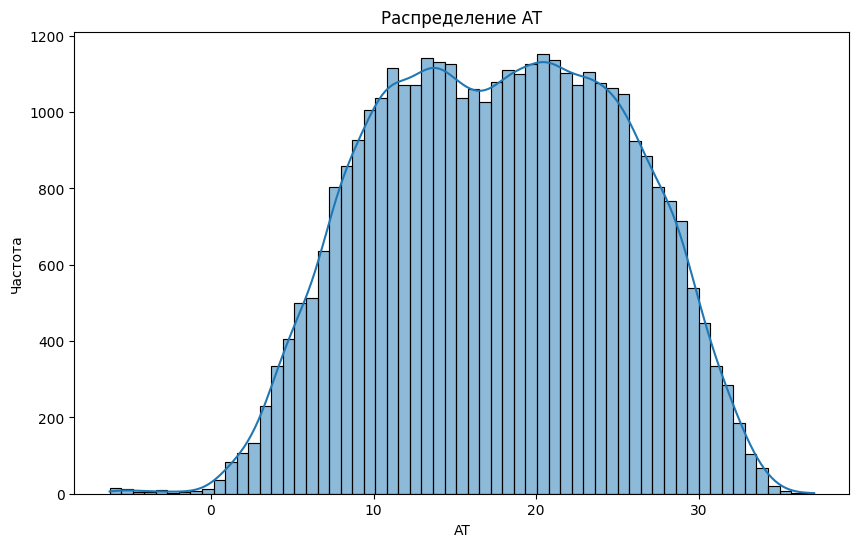

------
------------ Описание AP ---------------


count    36726.000000
mean      1013.071521
std          6.463155
min        985.850000
25%       1008.800000
50%       1012.600000
75%       1017.000000
max       1036.600000
Name: AP, dtype: float64

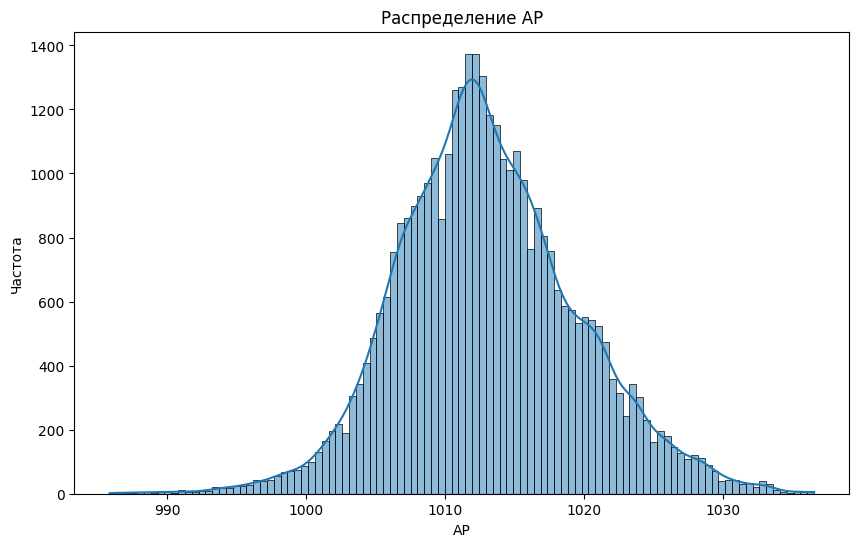

------
------------ Описание AH ---------------


count    36726.000000
mean        77.864274
std         14.461250
min         24.085000
25%         68.182500
50%         80.465500
75%         89.373750
max        100.200000
Name: AH, dtype: float64

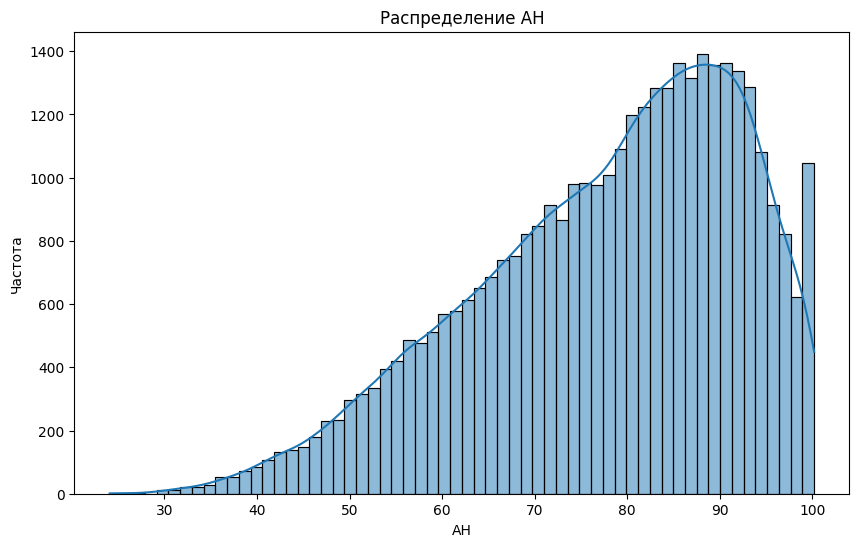

------
------------ Описание AFDP ---------------


count    36726.000000
mean         3.925410
std          0.773939
min          2.087400
25%          3.355525
50%          3.937450
75%          4.376800
max          7.610600
Name: AFDP, dtype: float64

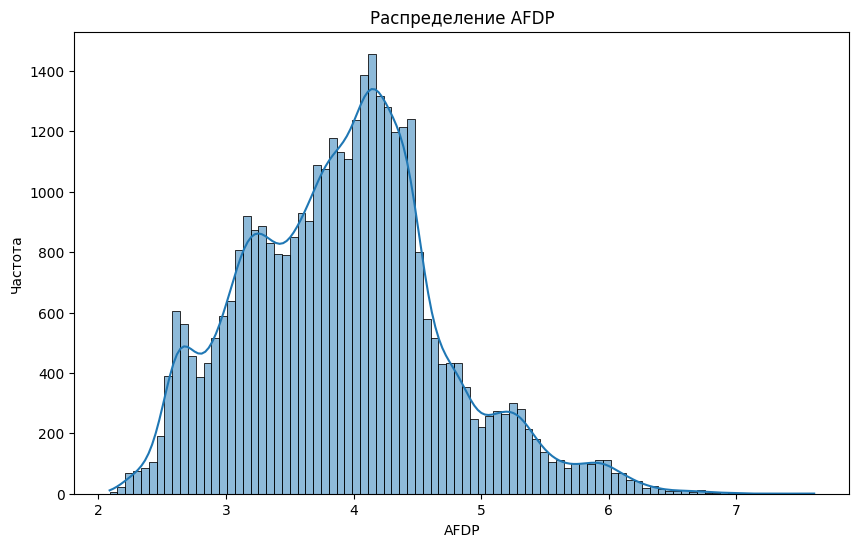

------
------------ Описание GTEP ---------------


count    36726.000000
mean        25.563537
std          4.196157
min         17.698000
25%         23.127250
50%         25.104500
75%         29.059000
max         40.716000
Name: GTEP, dtype: float64

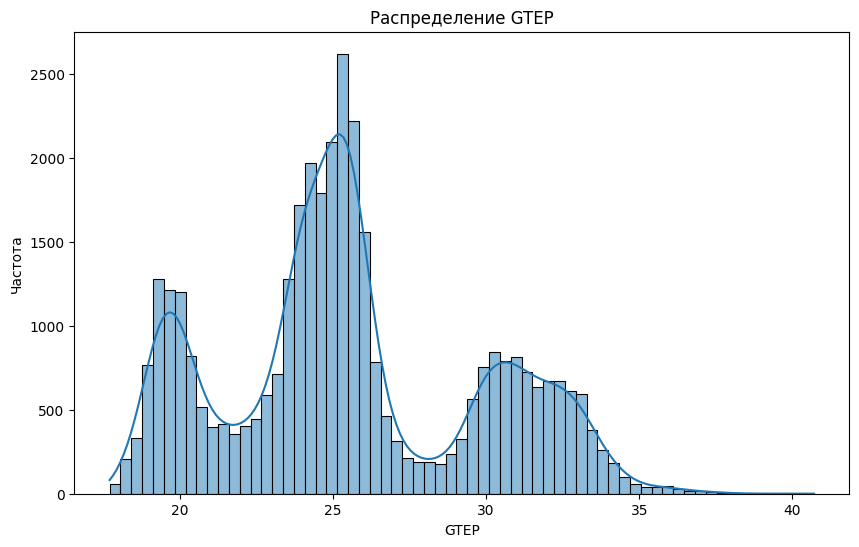

------
------------ Описание TIT ---------------


count    36726.000000
mean      1081.427166
std         17.537244
min       1000.800000
25%       1071.800000
50%       1085.900000
75%       1097.000000
max       1100.900000
Name: TIT, dtype: float64

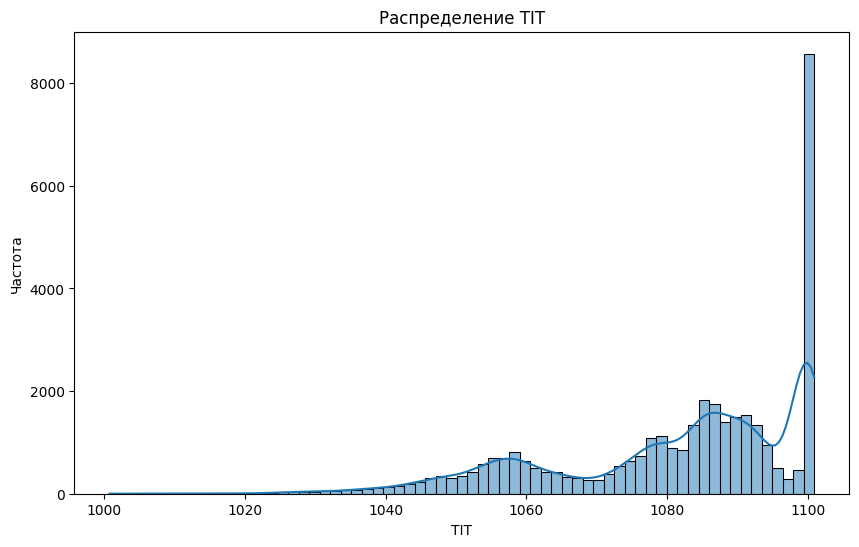

------
------------ Описание TAT ---------------


count    36726.000000
mean       546.158062
std          6.842901
min        511.040000
25%        544.720000
50%        549.880000
75%        550.040000
max        550.610000
Name: TAT, dtype: float64

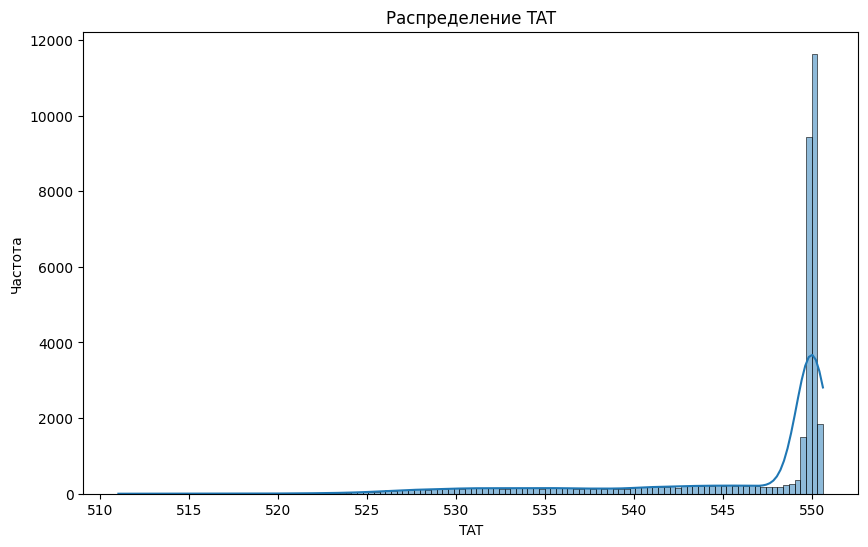

------
------------ Описание TEY ---------------


count    36726.000000
mean       133.506079
std         15.619558
min        100.020000
25%        124.450000
50%        133.730000
75%        144.080000
max        179.500000
Name: TEY, dtype: float64

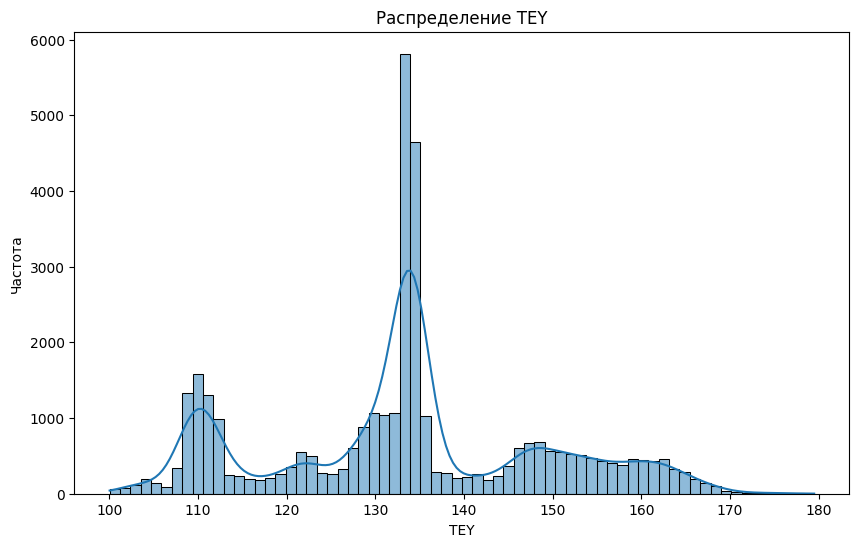

------
------------ Описание CDP ---------------


count    36726.000000
mean        12.060470
std          1.088861
min          9.851800
25%         11.434000
50%         11.965000
75%         12.853750
max         15.159000
Name: CDP, dtype: float64

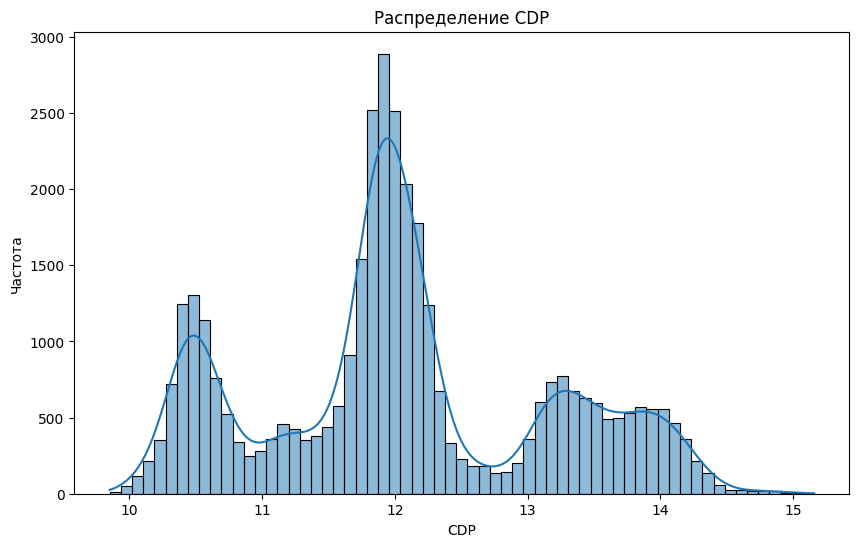

------
------------ Описание CO ---------------


count    36726.000000
mean         2.372627
std          2.262856
min          0.000388
25%          1.182325
50%          1.713700
75%          2.843350
max         44.103000
Name: CO, dtype: float64

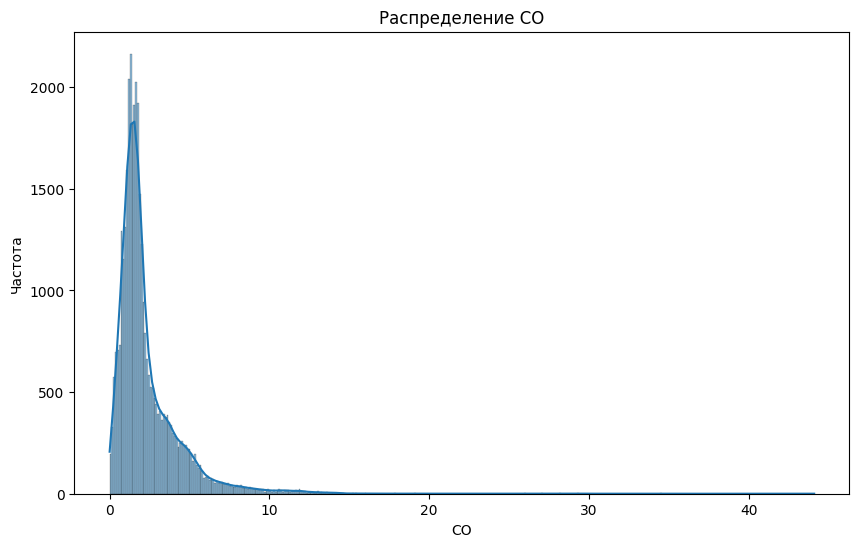

------
------------ Описание NOX ---------------


count    36726.000000
mean        65.296061
std         11.677402
min         25.905000
25%         57.164250
50%         63.851000
75%         71.549000
max        119.910000
Name: NOX, dtype: float64

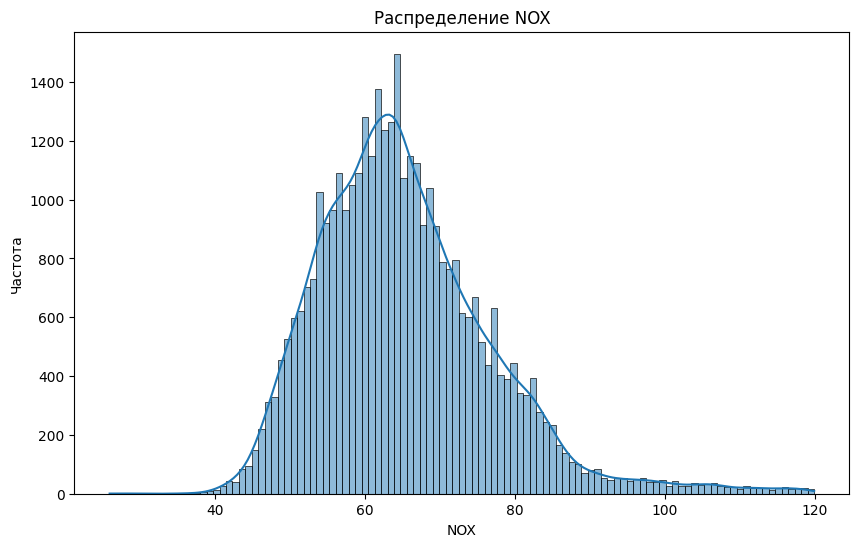

------


In [277]:
for col in cols:

    print(f'------------ Описание {col} ---------------')
    display(data[col].describe())

    plt.figure(figsize=(10, 6))
    sns.histplot(data[col], kde=True)
    plt.title(f'Распределение {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.show()  

    print(f'------')

* АТ (температура) - температура преимущественно теплая или жаркая т.к данные собирались в Турции
* AP (атмосферное давление) - распределение близко к нормальному, явных сильных выбросов не видно
* AH (Влажность воздуха) - большая часть наблюдений сосредоточена в области высоких значений влажности, вероятно это тоже связано с тем. что турбина в Турции
* AFDP (перепад давления на воздушном фильтре) - похоже. что у этого признака есть несколько пиков, вероятно это связано с особенностями работы турбины, распределение смещено влево
* GTEP (давление выхлопа газовой турбины) - заметно, что у признака явно несколько пиков, вероятно у турбины может быть несколько режимов работы
* TIT (температура на входе турбины) - начения сильно смещены к верхней границе диапазона, скорее всего у турбины есть определенная рабочая температура, а более низкие указывают либо на какой нибудь разгон или более слабые режимы работы
* TAT (температура после турбины) - признак сильно сконцентрирован около верхней границы диапазона, скорее всего температура после турбины поддерживается на определенном рабочем уровне
* TEY (выработка энергии турбиной) - заметно несколько пиков, особенно заметен пик где-то на уровне 135
* CDP (давление на выходе компрессора) - тоже имеет несколько пиков
* CO - признак сильно смещен влево, но есть длинный правый хвост, которые говорят о пвышенных выбросах
* NOX (выбросы оксидов азота) - признак немного смещен влево, но больше похож на нормальное распределение, но заметен правый хвост

По распределениям можно сказать, что скорее всего у турбины несколько режимов работы, которые влияют на показатели

### Смотрим корреляции

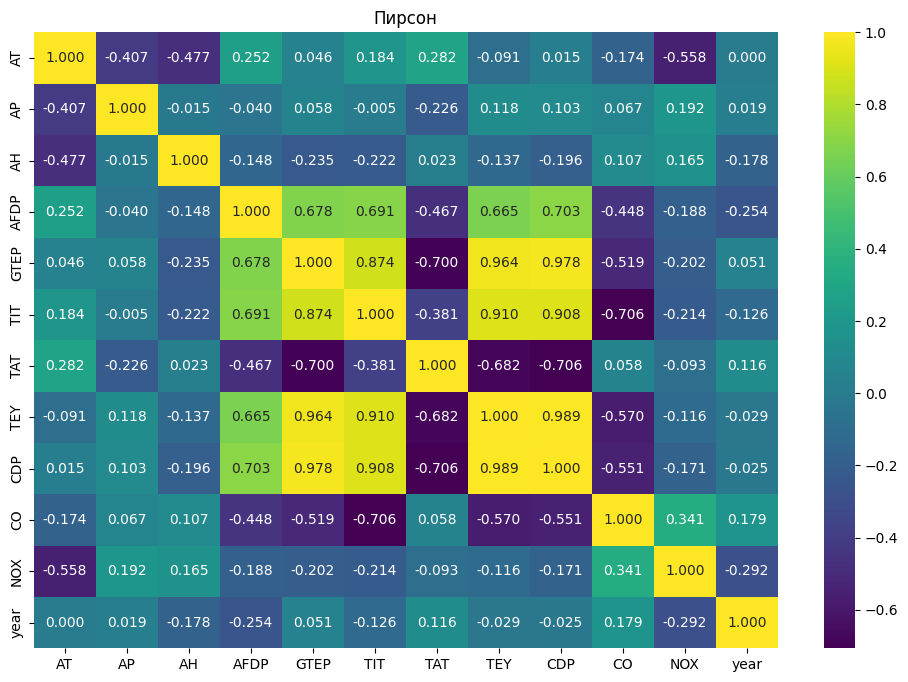

In [278]:
corr = data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='viridis')
plt.title('Пирсон')
plt.show()


В первую очередь видно, что рабочие параметры газовой турбины сильно связаны между собой как и предполагалось
* `TEY` и `CDP`: 0.989
* `GTEP` и `CDP`: 0.978
* `TEY` и `GTEP`: 0.964
* `TEY` и `TIT`: 0.910
* `TIT` и `CDP`: 0.908

Это говорит о том, что данные признаки совместно описывают рабочий режим турбины. При росте выработки энергии обычно растут давление на выходе компрессора, давление выхлопа и температура на входе турбины. Поэтому `TEY` можно рассматривать как удобный показатель нагрузки турбины

Для выбросов `CO` обнаружены заметные отрицательные связи с основными рабочими параметрами
* `CO` и `TIT`: -0.706
* `CO` и `TEY`: -0.570
* `CO` и `CDP`: -0.551
* `CO` и `GTEP`: -0.519
* `CO` и `AFDP`: -0.448

Для `NOX` cамая заметная связь не с нагрузкой турбины другими штучками
* `NOX` и `AT`: -0.558
* `NOX` и `CO`: 0.341
* `NOX` и `year`: -0.292
* `NOX` и `TIT`: -0.214
* `NOX` и `GTEP`: -0.202

Eсть умеренная положительная связь между `NOX` и `CO` `0.341`, то есть периоды повышенных выбросов одного загрязнителя частично могут совпадать с повышенными выбросами другого

In [279]:
phik_corr = data.phik_matrix()
phik_corr

interval columns not set, guessing: ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP', 'CO', 'NOX', 'year']


,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX,year
AT,1.000000,0.605885,0.609886,0.461780,0.593510,0.426365,0.516504,0.725475,0.688464,0.217837,0.586036,0.218611
AP,0.605885,1.000000,0.207972,0.221531,0.372873,0.220338,0.354038,0.463158,0.462787,0.149011,0.315661,0.239394
AH,0.609886,0.207972,1.000000,0.250385,0.368250,0.336827,0.188997,0.294495,0.368209,0.153260,0.203627,0.401832
AFDP,0.461780,0.221531,0.250385,1.000000,0.692228,0.702931,0.572548,0.679708,0.721555,0.501273,0.408752,0.458429
GTEP,0.593510,0.372873,0.368250,0.692228,1.000000,0.858523,0.846986,0.931719,0.957363,0.599318,0.524949,0.384961
TIT,0.426365,0.220338,0.336827,0.702931,0.858523,1.000000,0.707422,0.912940,0.905682,0.783491,0.613266,0.516718
TAT,0.516504,0.354038,0.188997,0.572548,0.846986,0.707422,1.000000,0.880816,0.907682,0.313590,0.362977,0.316750
TEY,0.725475,0.463158,0.294495,0.679708,0.931719,0.912940,0.880816,1.000000,0.976626,0.619478,0.517368,0.520809
CDP,0.688464,0.462787,0.368209,0.721555,0.957363,0.905682,0.907682,0.976626,1.000000,0.608698,0.498906,0.414766
CO,0.217837,0.149011,0.153260,0.501273,0.599318,0.783491,0.313590,0.619478,0.608698,1.000000,0.591118,0.219231


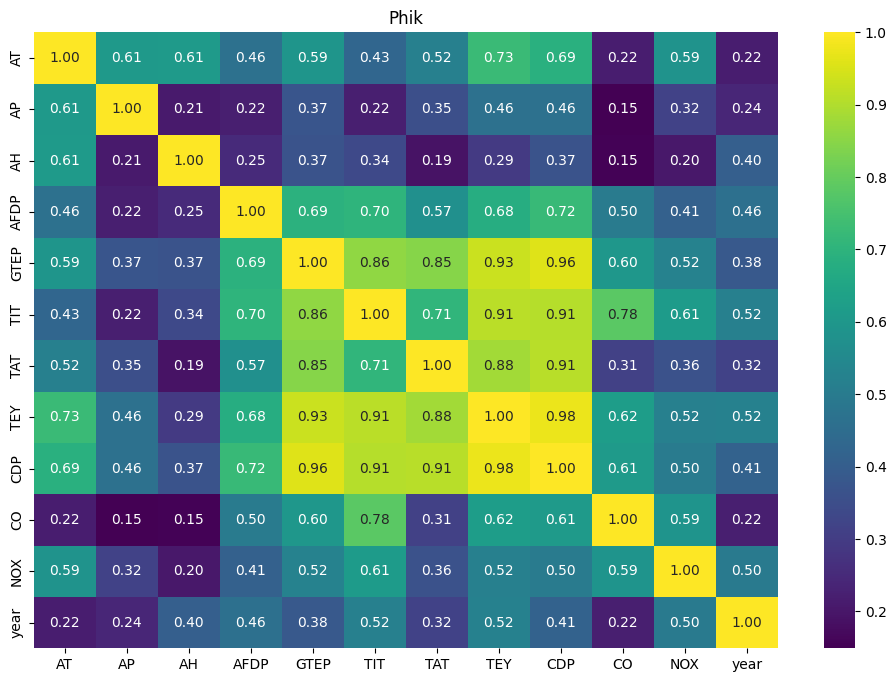

In [280]:
plt.figure(figsize=(12, 8))
sns.heatmap(phik_corr, annot=True, fmt='.2f', cmap='viridis')
plt.title('Phik')
plt.show()

Главное отличие Phik от Pearson заметно когда мы смотрим на `NOX`. В Pearson связь `NOX` с рабочими параметрами турбины была слабой, а тут же у нас
- `NOX` и `TIT`: Phik = 0.613
- `NOX` и `GTEP`: Phik = 0.525
- `NOX` и `TEY`: Phik = 0.517
- `NOX` и `CDP`: Phik = 0.499

Это говорит, о том что связь `NOX` с параметрами трубины нелинейная

## Смотримм scatter

In [281]:
clust = ['GTEP', 'CDP', 'TIT', 'TAT', 'AFDP']
X_cluster = data[clust]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(X_scaled)
data.head()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX,year,cluster
0,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,0.32663,81.952,2011,2
1,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,0.44784,82.377,2011,2
2,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,0.45144,83.776,2011,2
3,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,0.23107,82.505,2011,2
4,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,0.26747,82.028,2011,2


In [282]:
data.groupby('cluster')['TEY'].mean()

cluster
0    112.393030
1    154.810208
2    133.068544
Name: TEY, dtype: float64

In [283]:
cluster_map = {
    0: "low",
    1: "high",
    2: "medium"
}
data['load'] = data['cluster'].map(cluster_map)
data['load'].value_counts()

load
medium    19035
high       9002
low        8689
Name: count, dtype: int64

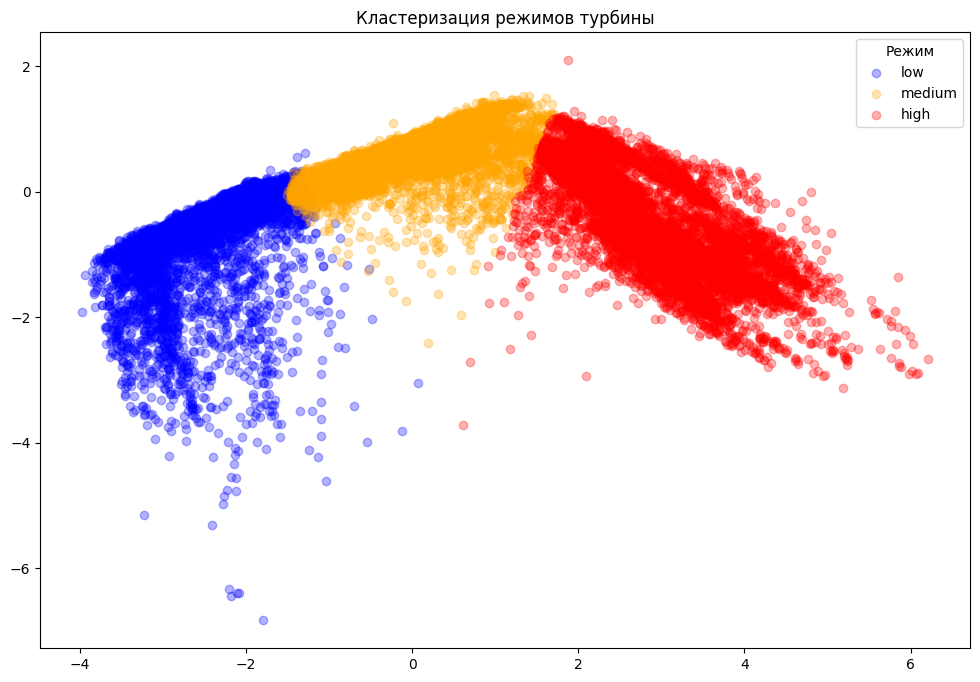

In [296]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
data['pca_1'] = X_pca[:, 0]
data['pca_2'] = X_pca[:, 1]

plt.figure(figsize=(12, 8))


low =  data[data['load'] == 'low']
medium = data[data['load'] == 'medium']
high = data[data['load'] == 'high']

plt.scatter(low['pca_1'], low['pca_2'], alpha=0.3, label='low', color = 'blue')
plt.scatter(medium['pca_1'], medium['pca_2'], alpha=0.3, label='medium', color = 'orange')
plt.scatter(high['pca_1'], high['pca_2'], alpha=0.3, label='high', color = 'red')

plt.title('Кластеризация режимов турбины')
plt.legend(title='Режим')
plt.show()